# Advanced Features

This tutorial covers MANTRA's advanced capabilities:

1. Callbacks: early stopping, logging, checkpoints
2. Reproducibility and seed management
3. Factor selection with ARD and `filter_factors`
4. Comparing models with different ranks
5. The cache system for scanpy integration
6. Association testing with metadata
7. Save/load workflow

## Setup

We use synthetic data throughout to keep things fast and self-contained.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import mantra
from mantra import MANTRA, DataGenerator

/Users/Buettner/projects/MANTRA/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Generate a shared dataset for all examples
gen = DataGenerator(n_samples=60, n_drugs=10, n_features=80, R=5)
gen.generate(seed=42)
data = gen.get_sim_data()
Y = data["Y_sim"]
print(f"Tensor shape: {Y.shape}")

Tensor shape: torch.Size([60, 10, 80])


## 1. Callbacks

MANTRA supports callbacks that are called after each training epoch. The
built-in callbacks are:

- **EarlyStoppingCallback**: stops training when loss stops improving
- **LogCallback**: logs training progress at regular intervals
- **CheckpointCallback**: saves model checkpoints to disk

You can also write custom callbacks by subclassing `Callback`.

### 1a. Early Stopping

In [3]:
from mantra.inference.callbacks import EarlyStoppingCallback

model_es = MANTRA(observations=Y, R=5, use_gpu=False)

early_stop = EarlyStoppingCallback(patience=50, min_delta=1e-3)

history_es, stopped = model_es.fit(
    n_epochs=5000,
    learning_rate=0.01,
    seed=42,
    callbacks=[early_stop],
    verbose=False,
)
print(f"Epochs run: {len(history_es)} / 5000")
print(f"Early stopped: {stopped}")
print(f"Final ELBO: {history_es[-1]:.2f}")

Epochs run: 1132 / 5000
Early stopped: True
Final ELBO: 71643.08


### 1b. Logging Callback

In [4]:
import logging

from mantra.inference.callbacks import LogCallback

# Enable logging to see LogCallback output
logging.basicConfig(level=logging.INFO, format="%(message)s")
logger = logging.getLogger("mantra")
logger.setLevel(logging.INFO)

model_log = MANTRA(observations=Y, R=5, use_gpu=False)
log_cb = LogCallback(log_every=200)

history_log, _ = model_log.fit(
    n_epochs=1000,
    learning_rate=0.01,
    seed=42,
    callbacks=[log_cb],
    verbose=False,
)
print(f"Training done. Final ELBO: {history_log[-1]:.2f}")

# Reset logging
logger.setLevel(logging.WARNING)

INFO:mantra.model.core:Using 1 particles
INFO:mantra.model.core:Preparing model and guide...
INFO:mantra.model.core:Preparing optimizer...
INFO:mantra.model.core:Preparing SVI...
INFO:mantra.model.core:Preparing training data...
INFO:mantra.model.core:Using complete dataset
INFO:mantra.model.core:Setting training seed to 42
INFO:mantra.model.core:Cleaning parameter store
INFO:mantra.model.core:Starting training...
INFO:mantra.inference.callbacks:Epoch 200: ELBO = 192426.2381
INFO:mantra.inference.callbacks:Epoch 400: ELBO = 130720.2044
INFO:mantra.inference.callbacks:Epoch 600: ELBO = 121913.2379
INFO:mantra.inference.callbacks:Epoch 800: ELBO = 117940.5255
INFO:mantra.model.core:Training complete. Final ELBO: 115725.73
INFO:mantra.inference.callbacks:Training complete. Final ELBO: 115725.7330


Training done. Final ELBO: 115725.73


### 1c. Checkpoint Callback

In [5]:
from mantra.inference.callbacks import CheckpointCallback

with tempfile.TemporaryDirectory() as tmpdir:
    checkpoint_dir = os.path.join(tmpdir, "checkpoints")

    model_ck = MANTRA(observations=Y, R=5, use_gpu=False)
    checkpoint_cb = CheckpointCallback(path=checkpoint_dir, every_n_epochs=200)

    history_ck, _ = model_ck.fit(
        n_epochs=1000,
        learning_rate=0.01,
        seed=42,
        callbacks=[checkpoint_cb],
        verbose=False,
    )

    checkpoints = sorted(os.listdir(checkpoint_dir))
    print(f"Saved checkpoints: {checkpoints}")

    # Load a checkpoint
    ckpt = torch.load(os.path.join(checkpoint_dir, checkpoints[-1]), weights_only=False)
    print(f"Last checkpoint: epoch={ckpt['epoch']}, loss={ckpt['loss']:.2f}")

Saved checkpoints: ['checkpoint_epoch_200.pt', 'checkpoint_epoch_400.pt', 'checkpoint_epoch_600.pt', 'checkpoint_epoch_800.pt']
Last checkpoint: epoch=800, loss=117940.53


### 1d. Combining Multiple Callbacks

In [6]:
model_multi = MANTRA(observations=Y, R=5, use_gpu=False)

history_multi, stopped = model_multi.fit(
    n_epochs=5000,
    learning_rate=0.01,
    seed=42,
    callbacks=[
        EarlyStoppingCallback(patience=100),
        LogCallback(log_every=500),
    ],
    verbose=False,
)
print(f"Epochs: {len(history_multi)}, Early stopped: {stopped}")

Epochs: 1345, Early stopped: True


## 2. Reproducibility and Seed Management

Setting a seed in `model.fit(seed=...)` ensures reproducible results via
`pyro.set_rng_seed()`. MANTRA also clears Pyro's parameter store before each
training run.

In [7]:
# Two runs with the same seed should produce identical results
model_a = MANTRA(observations=Y, R=5, use_gpu=False)
history_a, _ = model_a.fit(n_epochs=500, learning_rate=0.01, seed=123, verbose=False)

model_b = MANTRA(observations=Y, R=5, use_gpu=False)
history_b, _ = model_b.fit(n_epochs=500, learning_rate=0.01, seed=123, verbose=False)

# Compare final ELBO
print(f"Run A final ELBO: {history_a[-1]:.4f}")
print(f"Run B final ELBO: {history_b[-1]:.4f}")
print(f"Difference: {abs(history_a[-1] - history_b[-1]):.2e}")

# Compare embeddings
A1_a = model_a.get_sample_embeddings()
A1_b = model_b.get_sample_embeddings()
max_diff = torch.abs(A1_a - A1_b).max().item()
print(f"Max A1 difference: {max_diff:.2e}")

Run A final ELBO: 125074.8692
Run B final ELBO: 125074.8692
Difference: 0.00e+00
Max A1 difference: 0.00e+00


## 3. Factor Selection

### 3a. Automatic Relevance Determination (ARD)

MANTRA's Horseshoe prior includes ARD: factors that don't contribute to
explaining the data have their scale shrunk toward zero. After training with
more factors than needed, you can inspect which ones were retained.

In [8]:
# Fit with more factors than the true rank (5)
model_over = MANTRA(observations=Y, R=15, use_gpu=False)
history_over, _ = model_over.fit(
    n_epochs=2000, learning_rate=0.01, seed=42, verbose=False
)

r2 = mantra.tl.variance_explained(model_over)
print("Per-factor R-squared (15 factors, true rank = 5):")
print(r2["per_factor"])

Per-factor R-squared (15 factors, true rank = 5):
                 r2
Factor_0   0.216930
Factor_2   0.208018
Factor_12  0.186528
Factor_10  0.170826
Factor_5   0.144423
Factor_8   0.118045
Factor_6   0.117949
Factor_7   0.109849
Factor_9   0.107953
Factor_11  0.099401
Factor_4   0.096704
Factor_3   0.095161
Factor_13  0.094285
Factor_14  0.092276
Factor_1   0.079737


### 3b. filter_factors

`filter_factors` selects the top factors capturing a given fraction of variance.

In [9]:
# Keep factors capturing 95% of variance
top_95 = mantra.tl.filter_factors(model_over, r2_thresh=0.95)
print(f"Factors for 95% variance: {top_95}")

# Keep top 3 factors
top_3 = mantra.tl.filter_factors(model_over, r2_thresh=3)
print(f"Top 3 factors: {top_3}")

Factors for 95% variance: ['Factor_0', 'Factor_2', 'Factor_12', 'Factor_10', 'Factor_5', 'Factor_8']
Top 3 factors: ['Factor_0', 'Factor_2', 'Factor_12']


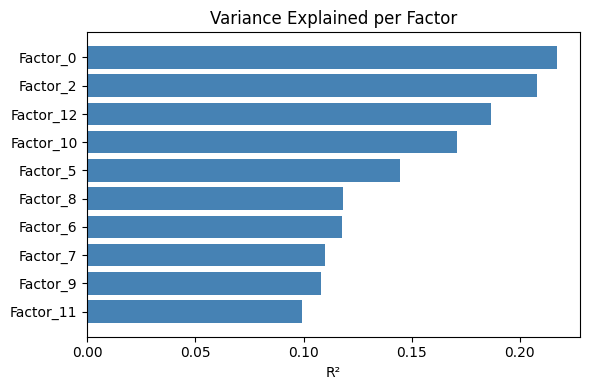

In [10]:
fig = mantra.pl.variance_explained(model_over, top=10)
plt.show()

## 4. Comparing Models with Different Ranks

A practical approach to choosing the rank is to fit several models and compare
reconstruction error and variance explained.

In [11]:
ranks = [3, 5, 8, 10, 15]
results = []

for r in ranks:
    m = MANTRA(observations=Y, R=r, use_gpu=False)
    hist, _ = m.fit(n_epochs=1500, learning_rate=0.01, seed=42, verbose=False)
    rmse = mantra.tl.rmse_loss(m.get_reconstructed(), Y).item()
    r2_total = mantra.tl.variance_explained(m)["total"]
    results.append({"R": r, "RMSE": rmse, "R2": r2_total, "Final_ELBO": hist[-1]})
    print(f"R={r:2d}  RMSE={rmse:.4f}  R2={r2_total:.4f}  ELBO={hist[-1]:.2f}")

results_df = pd.DataFrame(results)

R= 3  RMSE=3.5857  R2=0.6873  ELBO=131213.68
R= 5  RMSE=1.4798  R2=0.9467  ELBO=90890.25
R= 8  RMSE=0.9862  R2=0.9763  ELBO=73157.21
R=10  RMSE=0.9842  R2=0.9764  ELBO=74235.91
R=15  RMSE=0.9758  R2=0.9768  ELBO=76085.69


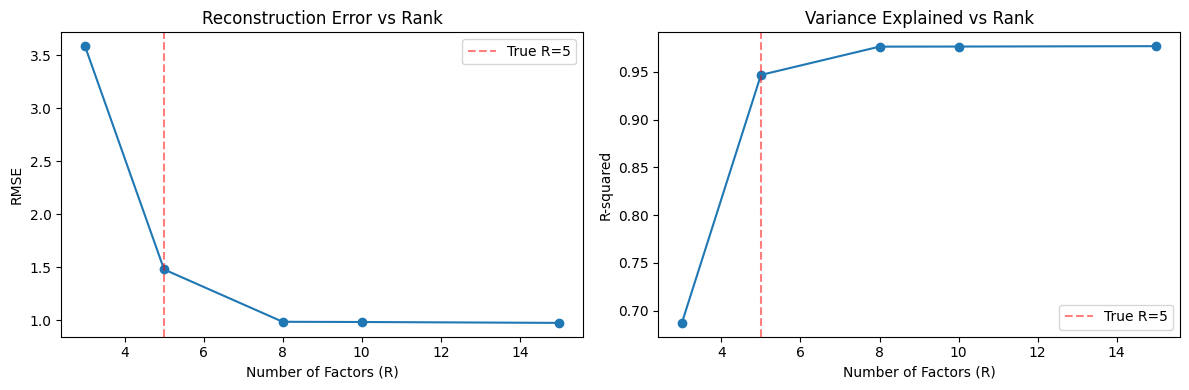

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(results_df["R"], results_df["RMSE"], "o-")
axes[0].set_xlabel("Number of Factors (R)")
axes[0].set_ylabel("RMSE")
axes[0].set_title("Reconstruction Error vs Rank")
axes[0].axvline(5, color="red", linestyle="--", alpha=0.5, label="True R=5")
axes[0].legend()

axes[1].plot(results_df["R"], results_df["R2"], "o-")
axes[1].set_xlabel("Number of Factors (R)")
axes[1].set_ylabel("R-squared")
axes[1].set_title("Variance Explained vs Rank")
axes[1].axvline(5, color="red", linestyle="--", alpha=0.5, label="True R=5")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. The Cache System

MANTRA bridges to scanpy by wrapping sample embeddings (A1) in an AnnData
object. This enables scanpy's neighbor graph, UMAP, clustering, and plotting
functions to operate directly on MANTRA's learned factors.

In [15]:
model_cache = MANTRA(observations=Y, R=5, use_gpu=False)
model_cache.fit(n_epochs=1000, learning_rate=0.01, seed=42, verbose=False)

# Setup cache (happens automatically when using tl/pl functions)
cache = mantra.tl.setup_cache(model_cache)
print(f"Cache AnnData: {cache.factor_adata}")
print(f"Obs columns: {list(cache.factor_adata.obs.columns)}")

Cache AnnData: AnnData object with n_obs × n_vars = 60 × 5
Obs columns: []


### 5a. Adding and Retrieving Metadata

In [16]:
# Create some synthetic metadata
np.random.seed(42)
groups = np.random.choice(["A", "B", "C"], size=60)
ages = np.random.randint(20, 80, size=60)

mantra.tl.add_metadata(model_cache, "group", groups)
mantra.tl.add_metadata(model_cache, "age", ages)

# Retrieve metadata
retrieved_groups = mantra.tl.get_metadata(model_cache, "group")
print(f"Groups: {retrieved_groups.value_counts().to_dict()}")
print(f"Age range: {mantra.tl.get_metadata(model_cache, 'age').min()}-{mantra.tl.get_metadata(model_cache, 'age').max()}")

Groups: {'C': 24, 'A': 18, 'B': 18}
Age range: 20-79


### 5b. Using Cache with Plotting

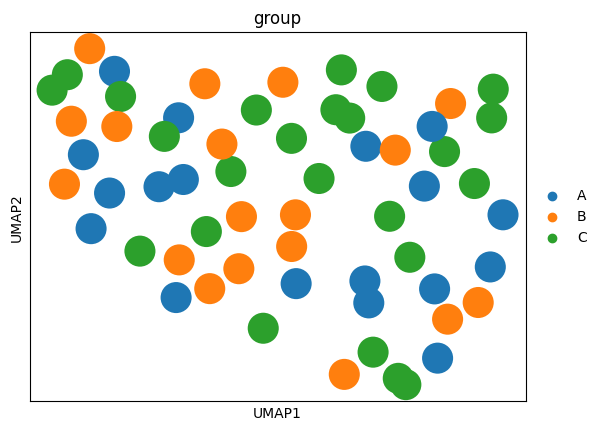

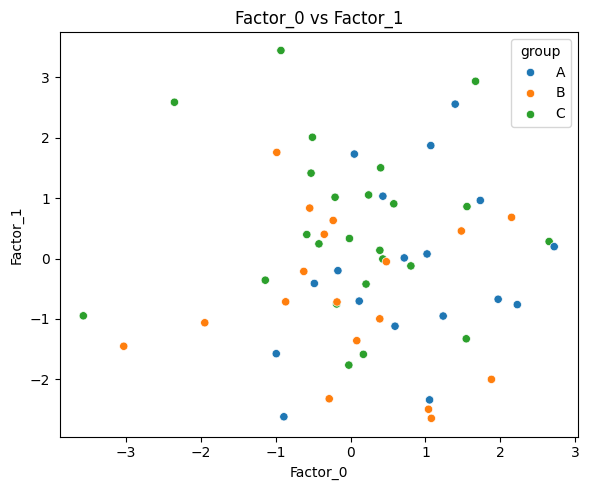

In [17]:
mantra.tl.neighbors(model_cache, n_neighbors=10)
mantra.tl.umap(model_cache)

fig = mantra.pl.embedding(model_cache, color="group", method="umap")
plt.show()

fig = mantra.pl.scatter(model_cache, x=0, y=1, color="group")
plt.show()

## 6. Association Testing

`mantra.tl.test` performs statistical tests between factor scores and sample
metadata. It automatically selects the appropriate test based on variable
type: Kruskal-Wallis for categorical, Spearman correlation for continuous.

In [18]:
metadata_df = pd.DataFrame(
    {"group": groups, "age": ages},
    index=model_cache.sample_names,
)

# Test associations (Kruskal-Wallis for categorical, Spearman for continuous)
test_results = mantra.tl.test(model_cache, metadata=metadata_df)
print("Association test results:")
print(test_results.to_string(index=False))

Association test results:
  factor metadata  statistic   pvalue  pvalue_adj  significant
Factor_0    group   5.062250 0.079569    0.397847        False
Factor_1    group   5.927687 0.051620    0.397847        False
Factor_0      age   0.199411 0.126631    0.422104        False
Factor_2    group   0.816348 0.664863    0.933668        False
Factor_3    group   0.839344 0.657262    0.933668        False
Factor_1      age   0.042534 0.746934    0.933668        False
Factor_2      age  -0.098135 0.455691    0.933668        False
Factor_3      age   0.057324 0.663528    0.933668        False
Factor_4    group   0.115073 0.944087    0.948229        False
Factor_4      age   0.008562 0.948229    0.948229        False


## 7. Save and Load

MANTRA persists models in a pickle-free format: JSON for metadata and NPZ for
numerical arrays. This ensures safety and portability across Python versions.

In [19]:
model_save = MANTRA(observations=Y, R=5, use_gpu=False)
model_save.sample_names = [f"Patient_{i}" for i in range(60)]
model_save.slice_names = [f"CellType_{i}" for i in range(10)]
model_save.feature_names = [[f"Gene_{i}" for i in range(80)]]
model_save.fit(n_epochs=1000, learning_rate=0.01, seed=42, verbose=False)

with tempfile.TemporaryDirectory() as tmpdir:
    save_path = os.path.join(tmpdir, "my_model")
    model_save.save(save_path)

    print(f"Saved files: {os.listdir(save_path)}")

    # Load the model
    model_loaded = MANTRA.load(save_path)
    print(f"\nLoaded model:")
    print(model_loaded)

    # Verify embeddings are identical
    A1_orig = model_save.get_sample_embeddings()
    A1_load = model_loaded.get_sample_embeddings()
    print(f"\nMax A1 difference after save/load: {torch.abs(A1_orig - A1_load).max().item():.2e}")

    # Verify names are preserved
    print(f"Sample names preserved: {(model_loaded.sample_names == model_save.sample_names).all()}")
    print(f"Slice names preserved: {(model_loaded.slice_names == model_save.slice_names).all()}")

Saved files: ['params.npz', 'metadata.json', 'data.npz']

Loaded model:
MANTRA Model
  n_views:    1
  n_samples:  60
  n_factors:  5
  n_features: view_0: 80
  trained:    True
  device:     cpu

Max A1 difference after save/load: 0.00e+00
Sample names preserved: True
Slice names preserved: True


## Summary

| Feature | Key Functions |
|---------|---------------|
| Early stopping | `EarlyStoppingCallback(patience, min_delta)` |
| Logging | `LogCallback(log_every)` |
| Checkpoints | `CheckpointCallback(path, every_n_epochs)` |
| Reproducibility | `model.fit(seed=42)` |
| Factor selection | `mantra.tl.filter_factors(model, r2_thresh)` |
| Rank comparison | Fit multiple models, compare RMSE/R-squared |
| Cache system | `mantra.tl.setup_cache()`, `add_metadata()`, `get_metadata()` |
| Association testing | `mantra.tl.test(model, metadata)` |
| Save/Load | `model.save(path)` / `MANTRA.load(path)` |